In [1]:
import re
import ast
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, accuracy_score, balanced_accuracy_score, log_loss
import typing
import pathlib
import pickle
import __main__
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()


# Embeddings Prediction Evaluations


## Goal

Use overnight news to predict the signs of returns. The prediction is done on firm-date level.

## Baseline Design:

We have collected 6 months of news headlines data from Jult 1st, 2025 to Dec 31st, 2025.

- We will use July + Aug data as training set: 1,253 firm-date observations, 13,036 relevant headlines. 
- We will use Sep-Dec data as test data: this includes 2,582 firm-date level observations, and 25,721 headlines.
- Since we use ChatGPT 5.2 to generate synthetic news, and the cutoff date for ChatGPT is on August 31st, we don't have to worry about look ahead bias. We used ChatGPT 5.2 Batch API to generate 22,658 firm-date level synthetic news, and sentiment scores. We later transform the sentiment score to binary labels.
- We also use ChatGPT 5.2 to generate synthetic labels only: this involves feeding the headlines in the training set to ChatGPT, and then obtain various synthetic sentiment scores for the same news. We then transform those synthetic scores to synthetic binary labels.
- We will use TF-IDF (Term Frequency-Inverse Document Frequency), to transform firm-date level news to a fixed dimensional sparse verctor. That is we treat each firm-date level observation, a collection of news headlines, as a document.

We start by training 4 models:

- A synthetic model: we train a model using synthetic news only using our ETEL procedure by making $300$ bootstrap draws: note here this is equivalent to solving $300$ independent unpenalized logistic regressions.
- A strong baseline model: we train an l2-logistic regression models using the training set, with various penalization grids: c= [1e-3, 0.0005, 1e-2, 0.05, 0.1, 0.5, 1, 10, 100]
- ETEL with synthetic news and synthetic labels: we fit our ETEL procedure using the training set, with various alpha grids: . Note we include $\alpha=0$, which does not use any synthetic news. Again this is equivalent to fitting $b$ unpenalized logistic regressions. 
- ETEL with synthetic labels only: during augmentation, we include real news data in the training set, and augmented them with synthetic labels.

For evaluation, we conduct 500 Monte-Carlo simulations. In each simulation:
- We randomly split half of the Sep-Dec data as validation set, and half of them as test set.
- For baseline model, we select the best $l_2$ penalty parameter based on validation AUC.
- For our framework,  we select the best $\alpha$ based on validation AUC.
- We then train larger models by combining the training set and validation set using the optimal $l_2$ penalty parameters for the baseline, and the optimal $\alpha$ parameter for our method. We then compare their performances in the test set.
- Note for the synthetic model, we did not do any tuning, and we simply evaluate them on the test set directly. 






In [2]:
def _load_firm_date_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    for col in ["headlines", "sources"]:
        if col in df.columns:
            df[col] = df[col].apply(ast.literal_eval)
    return df

train_df_50 = _load_firm_date_csv("firm_date_train_r50.csv")
val_df_50 = _load_firm_date_csv("firm_date_val_r50.csv")
test_df_50 = _load_firm_date_csv("firm_date_test_r50.csv")
HERE = pathlib.Path.home().joinpath("EL", "markdowns", "02-26-gen-ai-finance")
aug_df = _load_firm_date_csv(HERE / "news_generation_code" / "out_test_600" /"synthetic_firmdate.csv")
label_df = _load_firm_date_csv(HERE / "news_generation_code" / "synthetic_label_out" /"synthetic_label_wide.csv")

In [3]:
train_df_50.shape

(1253, 10)

In [4]:
model_output_dir = pathlib.Path("/Users/jiguangli/EL/models/gen-ai-finance")

with open(model_output_dir.joinpath("large_tfidf_genel_v1.pkl"), "rb") as f:
    mc_results = pickle.load(f)

In [5]:
test_results = mc_results["test_results"].copy()

## Test Set Performance

In [6]:
test_summary = (
    test_results.groupby("method", dropna=False)
    .agg(
        n_sims=("sim_id", "nunique"),
        mean_test_auc=("test_auc", "mean"),
        sd_test_auc=("test_auc", "std"),
        mean_test_acc=("test_accuracy", "mean"),
        sd_test_acc=("test_accuracy", "std"),
        median_test_auc=("test_auc", "median"),
        median_test_acc=("test_accuracy", "median"),
        min_test_auc=("test_auc", "min"),
        max_test_auc=("test_auc", "max"),
    )
    .reset_index()
    .sort_values("mean_test_auc", ascending=False)
    .reset_index(drop=True)
)
test_summary

,method,n_sims,mean_test_auc,sd_test_auc,mean_test_acc,sd_test_acc,median_test_auc,median_test_acc,min_test_auc,max_test_auc
0,synthetic_label_alpha_grid,500,0.574296,0.011448,0.560476,0.010998,0.574210,0.560806,0.538267,0.612882
1,augmented_alpha_grid,500,0.573385,0.011558,0.558542,0.011324,0.573268,0.557707,0.539372,0.611023
2,l2_logistic,500,0.559734,0.016276,0.547620,0.014260,0.559865,0.547250,0.510395,0.613584
3,alpha0_synthetic_only,500,0.518362,0.011853,0.523805,0.010137,0.518563,0.523625,0.486154,0.561769


**Pair-Wise AUC and Accuracy Differences**

p_win is the probability of our method wins accross 500 MC splits.


**augmented_alpha_grid v.s Baseline**

In [7]:
wide_auc = test_results.pivot(index="sim_id", columns="method", values="test_auc")
wide_acc = test_results.pivot(index="sim_id", columns="method", values="test_accuracy")

m0 = "augmented_alpha_grid"
m1 = "l2_logistic"

d_auc = wide_auc[m0] - wide_auc[m1]
d_acc = wide_acc[m0] - wide_acc[m1]

summary_diff = pd.DataFrame({
    "metric": ["AUC", "Accuracy"],
    "mean_diff": [d_auc.mean(), d_acc.mean()],
    "sd_diff": [d_auc.std(ddof=1), d_acc.std(ddof=1)],
    "se_diff": [d_auc.std(ddof=1)/np.sqrt(d_auc.notna().sum()),
                d_acc.std(ddof=1)/np.sqrt(d_acc.notna().sum())],
    "p_win": [(d_auc > 0).mean(), (d_acc > 0).mean()],  # win-rate across splits
})
summary_diff

,metric,mean_diff,sd_diff,se_diff,p_win
0,AUC,0.013651,0.016365,0.000732,0.794
1,Accuracy,0.010922,0.015629,0.000699,0.718


**Synthetic_label_alpha_grid v.s Baseline**

In [8]:
wide_auc = test_results.pivot(index="sim_id", columns="method", values="test_auc")
wide_acc = test_results.pivot(index="sim_id", columns="method", values="test_accuracy")

m0 = "synthetic_label_alpha_grid"
m1 = "l2_logistic"

d_auc = wide_auc[m0] - wide_auc[m1]
d_acc = wide_acc[m0] - wide_acc[m1]

summary_diff = pd.DataFrame({
    "metric": ["AUC", "Accuracy"],
    "mean_diff": [d_auc.mean(), d_acc.mean()],
    "sd_diff": [d_auc.std(ddof=1), d_acc.std(ddof=1)],
    "se_diff": [d_auc.std(ddof=1)/np.sqrt(d_auc.notna().sum()),
                d_acc.std(ddof=1)/np.sqrt(d_acc.notna().sum())],
    "p_win": [(d_auc > 0).mean(), (d_acc > 0).mean()],  # win-rate across splits
})
summary_diff

,metric,mean_diff,sd_diff,se_diff,p_win
0,AUC,0.014562,0.015943,0.000713,0.852
1,Accuracy,0.012855,0.014820,0.000663,0.794


**Synthetic_label_alpha_grid v.s. augmented_alpha_grid**

In [9]:
wide_auc = test_results.pivot(index="sim_id", columns="method", values="test_auc")
wide_acc = test_results.pivot(index="sim_id", columns="method", values="test_accuracy")

m0 = "synthetic_label_alpha_grid"
m1 = "augmented_alpha_grid"

d_auc = wide_auc[m0] - wide_auc[m1]
d_acc = wide_acc[m0] - wide_acc[m1]

summary_diff = pd.DataFrame({
    "metric": ["AUC", "Accuracy"],
    "mean_diff": [d_auc.mean(), d_acc.mean()],
    "sd_diff": [d_auc.std(ddof=1), d_acc.std(ddof=1)],
    "se_diff": [d_auc.std(ddof=1)/np.sqrt(d_auc.notna().sum()),
                d_acc.std(ddof=1)/np.sqrt(d_acc.notna().sum())],
    "p_win": [(d_auc > 0).mean(), (d_acc > 0).mean()],  # win-rate across splits
})
summary_diff

,metric,mean_diff,sd_diff,se_diff,p_win
0,AUC,0.000911,0.003810,0.000170,0.596
1,Accuracy,0.001933,0.007508,0.000336,0.568


## Validation Performance

In [10]:
val_summary = (
    test_results.groupby("method", dropna=False)
    .agg(
        n_sims=("sim_id", "nunique"),
        mean_selected_val_auc=("selected_val_auc", "mean"),
        sd_selected_val_auc=("selected_val_auc", "std"),
        mean_selected_val_acc=("selected_val_accuracy", "mean"),
        sd_selected_val_acc=("selected_val_accuracy", "std"),
    )
    .reset_index()
    .sort_values("mean_selected_val_auc", ascending=False)
    .reset_index(drop=True)
)
val_summary

,method,n_sims,mean_selected_val_auc,sd_selected_val_auc,mean_selected_val_acc,sd_selected_val_acc
0,augmented_alpha_grid,500,0.551062,0.011413,0.547046,0.009726
1,l2_logistic,500,0.550618,0.011180,0.541337,0.010440
2,synthetic_label_alpha_grid,500,0.549554,0.011415,0.547264,0.009910
3,alpha0_synthetic_only,500,0.517487,0.011792,0.523445,0.010137


## Validation $\alpha$ Tuning


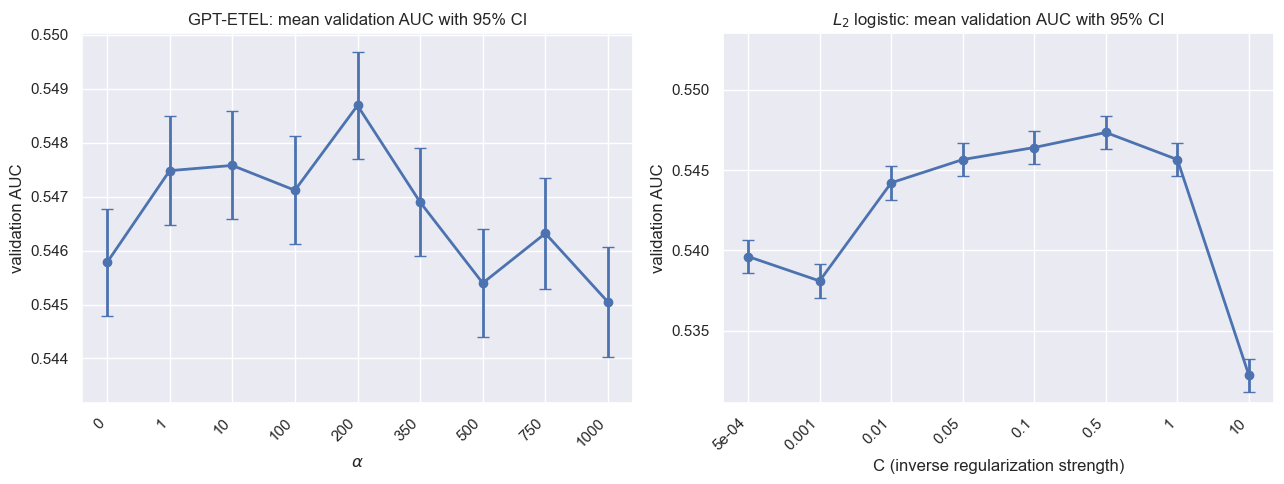

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _fmt_num(x: float) -> str:
    x = float(x)
    if x == 0:
        return "0"
    if 0 < abs(x) < 0.001:
        return f"{x:.0e}"
    if 0 < abs(x) < 0.01:
        return f"{x:g}"
    if abs(x - round(x)) < 1e-12:
        return str(int(round(x)))
    return f"{x:g}"

def _summarize_mean_ci(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:
    out = (
        df.groupby(x_col)[y_col]
        .agg(mean="mean", sd="std", n="count")
        .reset_index()
        .sort_values(x_col)
    )
    out["se"] = out["sd"] / np.sqrt(out["n"])
    out["ci95"] = 1.96 * out["se"]
    return out

def _prepare_alpha_summary(mc_results,
                           alphas_to_show=None,
                           use_best_tfidf_per_alpha=True,
                           method_name="validation_results_aug"):
    aug = mc_results[method_name].copy()
    aug["alpha"] = aug["alpha"].astype(float)

    if use_best_tfidf_per_alpha:
        aug = aug.groupby(["sim_id", "alpha"], as_index=False)["val_auc"].max()

    if alphas_to_show is not None:
        keep = set(float(a) for a in alphas_to_show)
        aug = aug[aug["alpha"].isin(keep)].copy()

    return _summarize_mean_ci(aug, x_col="alpha", y_col="val_auc")

def _prepare_l2_summary(mc_results,
                        c_values_to_show=None,
                        use_best_tfidf_per_c=True):
    l2 = mc_results["validation_results_l2"].copy()
    l2["c_value"] = l2["c_value"].astype(float)

    if use_best_tfidf_per_c:
        l2 = l2.groupby(["sim_id", "c_value"], as_index=False)["val_auc"].max()

    if c_values_to_show is not None:
        keep = set(float(c) for c in c_values_to_show)
        l2 = l2[l2["c_value"].isin(keep)].copy()

    return _summarize_mean_ci(l2, x_col="c_value", y_col="val_auc")

def _set_panel_ylim(ax,
                    means,
                    ci95,
                    pad_low_frac=0.10,
                    pad_high_frac=0.10,
                    extra_low=0.0,
                    extra_high=0.0):
    ymin = np.min(means - ci95)
    ymax = np.max(means + ci95)
    span = ymax - ymin

    if span <= 0:
        span = 0.001

    ax.set_ylim(
        ymin - pad_low_frac * span - extra_low,
        ymax + pad_high_frac * span + extra_high,
    )

def plot_val_auc_alpha_vs_l2(mc_results,
                             alphas_to_show=None,
                             c_values_to_show=None,
                             use_best_tfidf_per_alpha=True,
                             use_best_tfidf_per_c=True,
                             method_name="validation_results_aug"):
    alpha_sum = _prepare_alpha_summary(
        mc_results=mc_results,
        alphas_to_show=alphas_to_show,
        use_best_tfidf_per_alpha=use_best_tfidf_per_alpha,
        method_name=method_name,
    )

    l2_sum = _prepare_l2_summary(
        mc_results=mc_results,
        c_values_to_show=c_values_to_show,
        use_best_tfidf_per_c=use_best_tfidf_per_c,
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

    # Left panel: GPT-BETEL, tightly zoomed to show alpha fluctuation
    ax = axes[0]
    x_alpha = np.arange(len(alpha_sum))
    ax.errorbar(
        x_alpha,
        alpha_sum["mean"].to_numpy(),
        yerr=alpha_sum["ci95"].to_numpy(),
        fmt="o-",
        capsize=4,
        linewidth=2,
        markersize=6,
    )
    ax.set_xticks(x_alpha)
    ax.set_xticklabels([_fmt_num(a) for a in alpha_sum["alpha"]], rotation=45, ha="right")
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel("validation AUC")
    ax.set_title(r"GPT-ETEL: mean validation AUC with 95% CI")

    _set_panel_ylim(
        ax,
        alpha_sum["mean"].to_numpy(),
        alpha_sum["ci95"].to_numpy(),
        pad_low_frac=0.15,
        pad_high_frac=0.06,
    )

    # Right panel: L2 logistic, wider upper y-range so baseline appears lower
    ax = axes[1]
    x_c = np.arange(len(l2_sum))
    ax.errorbar(
        x_c,
        l2_sum["mean"].to_numpy(),
        yerr=l2_sum["ci95"].to_numpy(),
        fmt="o-",
        capsize=4,
        linewidth=2,
        markersize=6,
    )
    ax.set_xticks(x_c)
    ax.set_xticklabels([_fmt_num(c) for c in l2_sum["c_value"]], rotation=45, ha="right")
    ax.set_xlabel("C (inverse regularization strength)")
    ax.set_ylabel("validation AUC")
    ax.set_title(r"$L_2$ logistic: mean validation AUC with 95% CI")

    _set_panel_ylim(
        ax,
        l2_sum["mean"].to_numpy(),
        l2_sum["ci95"].to_numpy(),
        pad_low_frac=0.04,
        pad_high_frac=0.3,
    )

    plt.tight_layout()
    return fig, axes


ALPHAS_TO_SHOW = [0.0, 1.0, 10.0, 100.0, 200.0, 350.0, 500.0, 750.0, 1000.0]
L2_GRID = [5e-4, 1e-3, 1e-2, 0.05, 0.1, 0.5, 1, 1, 10]

fig, axes = plot_val_auc_alpha_vs_l2(
    mc_results,
    alphas_to_show=ALPHAS_TO_SHOW,
    c_values_to_show=L2_GRID,
    method_name="validation_results_synthetic_label_aug",
)

fig.savefig("val_auc_alpha_vs_l2_new.pdf", format="pdf", bbox_inches="tight")
plt.show()